In [40]:
import csv
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

Skrypt pozwoli na stworzenie modelu i wytrenowanie go. Po zakończonym trenowaniu należy wyciągnąć wartości weight i bias z warstw liniowych i przekopiować je do swojego modelu napisanego w Numpy (przekopiować wartości). Proszę o zapisanie wykresów trenowania i pokazanie ich na następnych zajęciach (może być w formie surowej po prostu screenów).

In [41]:
# Stwórz odpowiedni model w miejsce kropek: model z jedną warstwą ukrytą z 5 neuronami, model z jedną warstwa ukrytą z 10 neuronami, model z dwiema warstwami ukrytymi z 5 neuronami.
# Do stworzenia modelu wykorzystaj: nn.Sequential, nn.Linear, nn.Sigmoid
# nn.Linear - https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
# nn.Sequential - https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
# nn.Sigmoid - https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html

# Trenujemy i testujemy po jednym modelu na raz. Testowanie następnego modelu wymaga włączenie wszystkich komórek jeszcze raz.

model = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Sigmoid(),
    nn.Linear(in_features=10, out_features=1),
    nn.Sigmoid(),
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=10, out_features=1, bias=True)
  (3): Sigmoid()
)


In [42]:
# Ustal parametry

# Ile kroków ma zostać wykonane podczas treningu. Dlugosc treningu to int
# Długość treningu pomiędzy bazami danych może się drastycznie różnić. Trening może potrwać kilka, kilkanaście minut.
# Gpu można włączyć w ustawieniach "change runtime type" i wybrać T4 GPU - ta opcja jest bezpłatnie dostępna z limitem.
# Proponuję trenować bazę danych steps na ponad 20k, wartość warto dobrać te wartość na podstawie dopasowania na końcu na wykresie i wartości błędu.
# Jeśli model nie jest wystarczająco wytrenowany to można kontynuować trenowanie za pomocą ponownego odpalenia komórki z komentarzem # Trening
dlugosc_treningu = 500000

# Czy znormalizować dane wejsciowe i wyjsciowe. Czy znormalizowac to bool
czy_znormalizowac = 1

In [43]:
# Załaduj dane uczące. Wpisz w miejsce kropek numer bazy danych

dataset_id = 1

if dataset_id == 0:
  # Dataset 1
  data = csv.reader(open('../datasets/regression/square-simple-training.csv'))
  test_data = csv.reader(open('../datasets/regression/square-simple-test.csv'))
elif dataset_id == 1:
  # Dataset 2
  data = csv.reader(open('../datasets/regression/steps-large-training.csv'))
  test_data = csv.reader(open('../datasets/regression/steps-large-test.csv'))
else:
  assert False, f"Wybrana baza danych nie jest dostępna."

In [44]:
# Jeżeli jest dostępne GPU to wykonaj trening na GPU, jeśli nie to na CPU

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Trening zostanie wykonany na {device}")

Trening zostanie wykonany na cuda:0


In [45]:
# Przygotuj dane uczące
x_list = []
y_list = []
for i, row in enumerate(data):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    x_list.append(x)
    y_list.append(y)

# Przygotuj dane testujace
test_x_list = []
test_y_list = []
for i, row in enumerate(test_data):
  if i > 0:
    _,x,y = row
    x = float(x)
    y = float(y)
    test_x_list.append(x)
    test_y_list.append(y)

In [46]:
# Funkcja straty
criterion = nn.MSELoss()
# Optymalizator
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

In [47]:
x_tensor = torch.tensor(x_list, dtype=torch.float32).reshape(-1, 1).to(device)
y_tensor = torch.tensor(y_list, dtype=torch.float32).reshape(-1, 1).to(device)

if czy_znormalizowac:
    x_min, x_max = x_tensor.min(), x_tensor.max()
    y_min, y_max = y_tensor.min(), y_tensor.max()
    x_train = (x_tensor - x_min) / (x_max - x_min)
    y_train = (y_tensor - y_min) / (y_max - y_min)
else:
    x_train = x_tensor
    y_train = y_tensor

# Pętla treningowa
for i in range(dlugosc_treningu):
    # Predykcja
    y_pred = model(x_train)

    # Obliczanie straty
    loss = criterion(y_pred, y_train)

    # Optymalizacja
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Logowanie co 1000 kroków
    if i % 1000 == 0:
        print(f"Krok: {i}, Loss: {loss.item():.6f}")

# Przygotowanie danych do wykresu
with torch.no_grad():
    x_to_plot = x_tensor.cpu().tolist()
    y_to_plot = y_tensor.cpu().tolist()

    if czy_znormalizowac:
        # Odwracamy normalizację dla predykcji do celów wizualnych
        y_pred_unnorm = y_pred * (y_max - y_min) + y_min
        y_pred_to_plot = y_pred_unnorm.cpu().tolist()
    else:
        y_pred_to_plot = y_pred.cpu().tolist()

print("\nTrening zakończony.")
if czy_znormalizowac:
    print(f"Finalny Loss (znormalizowany): {loss.item():.6f}")

Krok: 0, Loss: 0.209404
Krok: 1000, Loss: 0.109703
Krok: 2000, Loss: 0.066854
Krok: 3000, Loss: 0.023995
Krok: 4000, Loss: 0.012535
Krok: 5000, Loss: 0.010627
Krok: 6000, Loss: 0.010431
Krok: 7000, Loss: 0.010411
Krok: 8000, Loss: 0.010388
Krok: 9000, Loss: 0.010351
Krok: 10000, Loss: 0.010285
Krok: 11000, Loss: 0.010154
Krok: 12000, Loss: 0.009987
Krok: 13000, Loss: 0.009775
Krok: 14000, Loss: 0.009500
Krok: 15000, Loss: 0.009176
Krok: 16000, Loss: 0.008852
Krok: 17000, Loss: 0.008561
Krok: 18000, Loss: 0.008317
Krok: 19000, Loss: 0.008121
Krok: 20000, Loss: 0.007965
Krok: 21000, Loss: 0.007843
Krok: 22000, Loss: 0.007764
Krok: 23000, Loss: 0.007712
Krok: 24000, Loss: 0.007666
Krok: 25000, Loss: 0.007624
Krok: 26000, Loss: 0.007571
Krok: 27000, Loss: 0.007499
Krok: 28000, Loss: 0.007428
Krok: 29000, Loss: 0.007358
Krok: 30000, Loss: 0.007279
Krok: 31000, Loss: 0.007186
Krok: 32000, Loss: 0.007082
Krok: 33000, Loss: 0.006956
Krok: 34000, Loss: 0.006797
Krok: 35000, Loss: 0.006606
Krok:

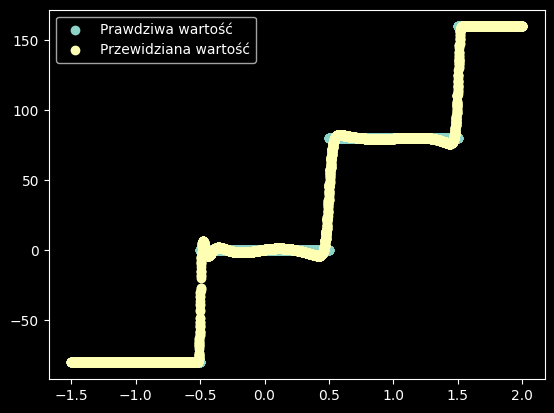

In [48]:
# Wyświetl jak wygląda predykcja modelu dla ostatniego kroku

plt.scatter(x_to_plot, y_to_plot)
plt.scatter(x_to_plot, y_pred_to_plot)
plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
plt.show()

In [49]:
# Przetestuj model na zbiorze testowym

test_x_to_plot = []
test_y_to_plot = []
test_y_pred_to_plot = []


x = torch.tensor(test_x_list).reshape(-1,1).to(device)
y = torch.tensor(test_y_list).reshape(-1,1).to(device)

if czy_znormalizowac:
  x_normalized = (x - x_min) / (x_max - x_min)
  y_normalized = (y - y_min) / (y_max - y_min)
else:
  x_normalized = x
  y_normalized = y

y_pred = model(x_normalized)

test_x_to_plot = test_x_to_plot + x.tolist()
test_y_to_plot = test_y_to_plot + y.tolist()
test_y_pred_to_plot = test_y_pred_to_plot + (y_pred*(y_max - y_min) + y_min).tolist()

loss = criterion(y_pred, y_normalized)

if czy_znormalizowac:
  print(f"Znormalizowana finalna wartość funkcji straty: {loss.item()}")
  normalized_loss = criterion( y_pred*(y_max - y_min) + y_min , y)
  print(f"Nieznormalizowana finalna wartość funkcji straty: {normalized_loss.item()}")
else:
  print(f"Nieznormalizowana finalna wartość funkcji straty: {loss.item()}")

Znormalizowana finalna wartość funkcji straty: 0.00028963168733753264
Nieznormalizowana finalna wartość funkcji straty: 16.682781219482422


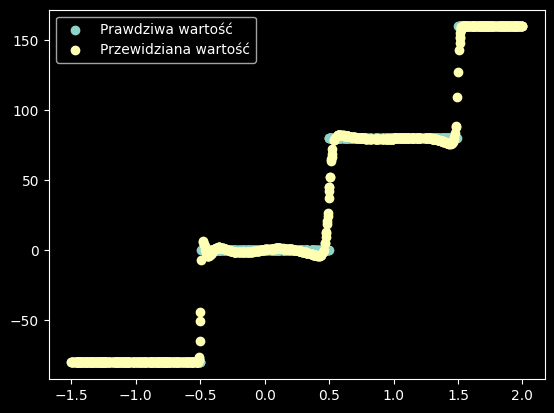

In [50]:
# Wyświetl prawdziwą wartość funkcji i przewidzianą wartość nieznormalizowaną

plt.scatter(test_x_to_plot, test_y_to_plot)
plt.scatter(test_x_to_plot, test_y_pred_to_plot)
plt.legend(['Prawdziwa wartość', 'Przewidziana wartość'])
plt.show()

In [51]:
# Funkcja do wyciągania wag z warstw liniowych

def get_weights_and_bias(linear_layer):
    print(f"Waga: {linear_layer.weight.data.cpu().numpy()}")
    print(f"Bias: {linear_layer.bias.data}")

# Przykład wyciągniecia wag z pierwszej warstwy liniowej
layer = model[0]
get_weights_and_bias(layer)

Waga: [[ 167.10422  ]
 [-129.04227  ]
 [ -14.221458 ]
 [  15.357367 ]
 [  -2.5011332]
 [ -42.83275  ]
 [  -8.53569  ]
 [-232.37714  ]
 [ 240.6287   ]
 [ 112.8683   ]]
Bias: tensor([ -47.5954,   34.0922,    5.3548,  -15.9457,    0.6873,   53.1643,
           2.7637,  132.6393, -211.2632,  -28.6108], device='cuda:0')


In [52]:
# Wyciągnij wagi ze wszystkich warstw liniowych i wklej je do swojego modelu w numpy.
# Uważaj na orientację wagi, być może trzeba będzie ją transponować!!! Pytorch może inaczej wymnażać X i weights niż wasz kod.

# Tu zrób kod
layer = model[2]
get_weights_and_bias(layer)

Waga: [[ -21.362461  -181.04843     -7.455148    -9.152156   -10.7967615
    -3.3268468   16.374033    -1.6013094  153.90599     21.354898 ]]
Bias: tensor([6.2844], device='cuda:0')
